# Member 3 — Outlier Removal

**Technique:** Remove exact duplicate images and resolution/brightness outliers using the IQR rule.

## Why this dataset needs it
Duplicate leaves leak into both train and test if not removed. Extreme tiny/huge or near-black frames are often capture artefacts and distort color histograms.


In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Resolve Group_Deliverable root whether cwd is notebooks/ or deliverable root
HERE = Path.cwd().resolve()
ROOT = None
for p in (HERE, *HERE.parents):
    if (p / "src" / "preprocess_utils.py").exists():
        ROOT = p
        break
    if (p / "Group_Deliverable" / "src" / "preprocess_utils.py").exists():
        ROOT = p / "Group_Deliverable"
        break
if ROOT is None:
    raise FileNotFoundError("Run from progress/Group_Deliverable or its notebooks/ folder.")

sys.path.insert(0, str(ROOT / "src"))
from preprocess_utils import (
    SEED, SOURCE_URL, DOI, FOLDERS, CLASSES, paths,
    inventory_table, discover_images, audit_images,
    remove_exact_duplicates, iqr_mask, extract_feature_matrix, read_rgb,
    stratified_sample, draw_process_flow,
)

P = paths(ROOT)
RAW, VIZ, OUT, LOGS = P["raw"], P["viz"], P["outputs"], P["logs"]
for d in (VIZ, OUT, LOGS):
    d.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(SEED)
PIPELINE_STEPS = [
    "1 Missing\ndata",
    "2 Categorical\nencoding",
    "3 Outlier /\nduplicate",
    "4 Feature\nengineering",
    "5 Scaling",
    "6 SelectKBest\n+ PCA",
]
print("Deliverable root:", ROOT)
print("Raw data:", RAW)
print("Dataset:", SOURCE_URL, "| DOI:", DOI)


Deliverable root: D:\SLIIT\projectr\Dataset_Train\progress\Group_Deliverable
Raw data: D:\SLIIT\projectr\Dataset_Train\progress\Group_Deliverable\data\raw
Dataset: https://ieee-dataport.org/open-access/leaves-indias-most-famous-basil-plant-leaves-quality-dataset | DOI: 10.21227/a4f6-4413


## 0. Process diagram — where this step sits in the pipeline


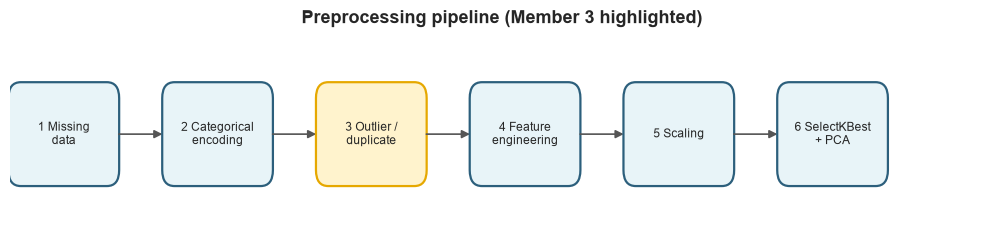

In [2]:
fig, _ = draw_process_flow(
    PIPELINE_STEPS,
    title="Preprocessing pipeline (Member 3 highlighted)",
    highlight=2,
)
fig.savefig(VIZ / "m3_process_flow.png", dpi=150, bbox_inches="tight")
plt.show()


## 1. Start from encoded metadata / audit, drop duplicates & IQR outliers


In [3]:
src = OUT / "m2_encoded_metadata.csv"
if src.exists():
    df = pd.read_csv(src)
else:
    df, _ = audit_images(RAW)
    print("Warning: m2 output missing; using fresh audit.")

before = len(df)
df_unique, n_dup = remove_exact_duplicates(df)
print(f"Exact pixel duplicates removed: {n_dup} (kept {len(df_unique)} / {before})")

# IQR on resolution and green-channel brightness (basil is green-dominant)
mask_px = iqr_mask(df_unique["pixels"], k=1.5)
mask_g = iqr_mask(df_unique["mean_g"], k=1.5)
keep = mask_px & mask_g
removed = df_unique.loc[~keep].copy()
clean = df_unique.loc[keep].reset_index(drop=True)

print(f"IQR outliers removed: {len(removed)}")
print(f"Final cleaned rows: {len(clean)}")
print(clean["label"].value_counts())

clean.to_csv(OUT / "m3_cleaned_no_outliers.csv", index=False)
removed.to_csv(OUT / "m3_removed_outliers.csv", index=False)
(LOGS / "m3_outlier_summary.json").write_text(
    json.dumps({
        "before": before,
        "duplicates_removed": int(n_dup),
        "iqr_removed": int(len(removed)),
        "after": int(len(clean)),
        "class_counts": {str(k): int(v) for k, v in clean["label"].value_counts().items()},
    }, indent=2),
    encoding="utf-8",
)


Exact pixel duplicates removed: 7 (kept 1124 / 1131)
IQR outliers removed: 48
Final cleaned rows: 1076
label
Healthy      609
Unhealthy    467
Name: count, dtype: int64


151

## 2. EDA visualizations — boxplots, before/after counts, outlier scatter


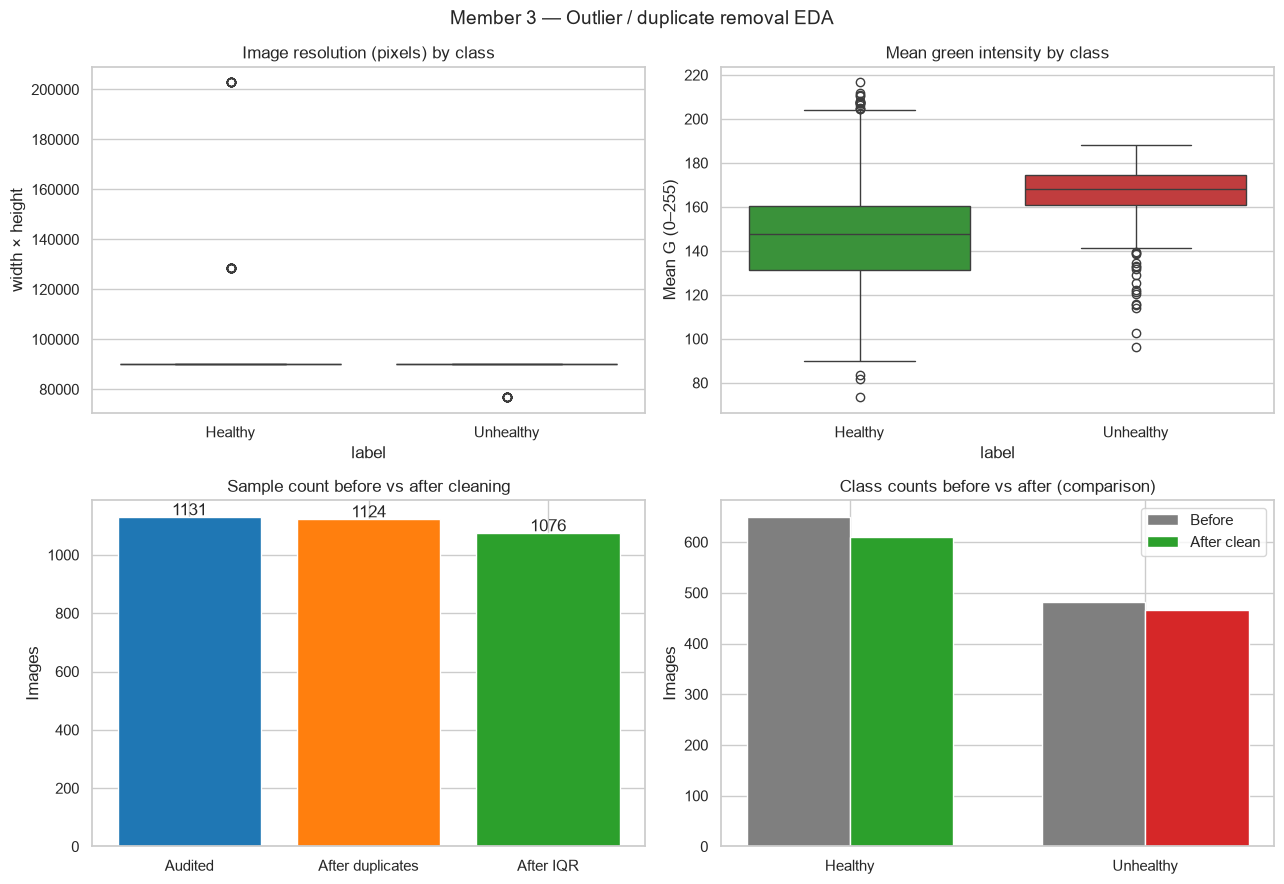

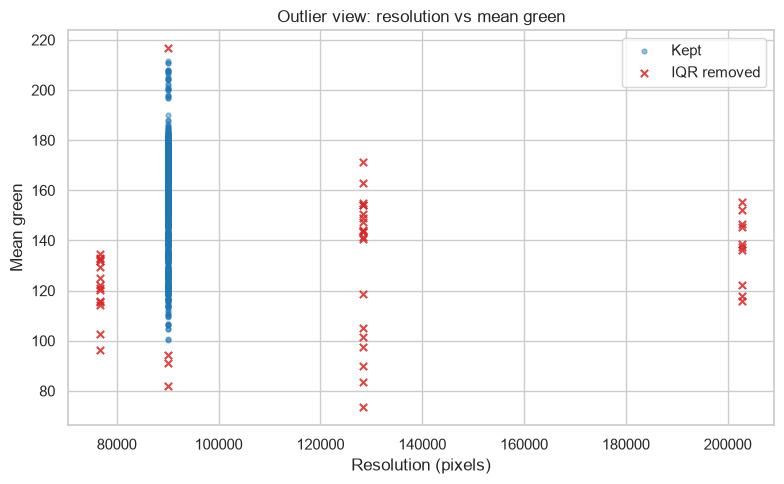

Interpretation: points far outside the whiskers are candidates for IQR removal; both classes should still remain after cleaning.


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.boxplot(data=df_unique, x="label", y="pixels", hue="label", order=CLASSES, ax=axes[0, 0], palette=["#2ca02c", "#d62728"], legend=False)
axes[0, 0].set_title("Image resolution (pixels) by class")
axes[0, 0].set_ylabel("width × height")

sns.boxplot(data=df_unique, x="label", y="mean_g", hue="label", order=CLASSES, ax=axes[0, 1], palette=["#2ca02c", "#d62728"], legend=False)
axes[0, 1].set_title("Mean green intensity by class")
axes[0, 1].set_ylabel("Mean G (0–255)")

# Before / after pipeline counts (comparison bars)
stages = ["Audited", "After duplicates", "After IQR"]
stage_counts = [before, len(df_unique), len(clean)]
axes[1, 0].bar(stages, stage_counts, color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[1, 0].set_title("Sample count before vs after cleaning")
axes[1, 0].set_ylabel("Images")
for i, v in enumerate(stage_counts):
    axes[1, 0].text(i, v + 5, str(v), ha="center")

# Class counts before vs after (grouped comparison)
before_cls = df["label"].value_counts().reindex(CLASSES).fillna(0)
after_cls = clean["label"].value_counts().reindex(CLASSES).fillna(0)
x = np.arange(len(CLASSES))
w = 0.35
axes[1, 1].bar(x - w / 2, before_cls.values, width=w, label="Before", color="#7f7f7f")
axes[1, 1].bar(x + w / 2, after_cls.values, width=w, label="After clean", color=["#2ca02c", "#d62728"])
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(CLASSES)
axes[1, 1].set_title("Class counts before vs after (comparison)")
axes[1, 1].set_ylabel("Images")
axes[1, 1].legend()

fig.suptitle("Member 3 — Outlier / duplicate removal EDA", fontsize=14)
fig.tight_layout()
fig.savefig(VIZ / "m3_outlier_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

# Extra: scatter of resolution vs green, mark removed outliers
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(clean["pixels"], clean["mean_g"], s=12, alpha=0.45, c="#1f77b4", label="Kept")
if len(removed):
    ax.scatter(removed["pixels"], removed["mean_g"], s=28, alpha=0.85, c="#d62728", marker="x", label="IQR removed")
ax.set_xlabel("Resolution (pixels)")
ax.set_ylabel("Mean green")
ax.set_title("Outlier view: resolution vs mean green")
ax.legend()
fig.tight_layout()
fig.savefig(VIZ / "m3_outlier_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Interpretation: points far outside the whiskers are candidates for IQR removal; both classes should still remain after cleaning.")
